Ejercicio 1

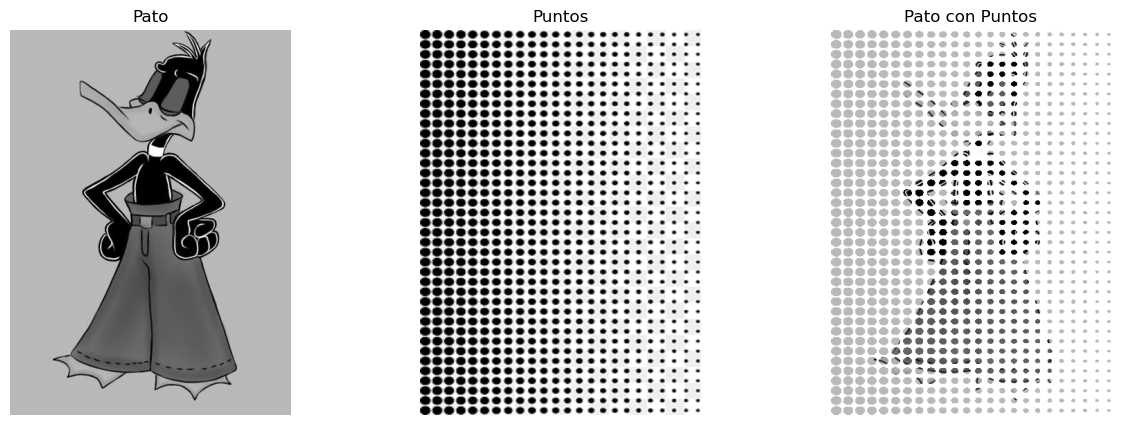

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

pato = cv2.imread('pato.jpg', 0)
puntos = cv2.imread('puntos.png', 0)

puntos = cv2.resize(puntos, (pato.shape[1], pato.shape[0]))
puntos_bin = cv2.threshold(puntos, 127, 255, cv2.THRESH_BINARY_INV)[1]

img = cv2.bitwise_and(pato, pato, mask=puntos_bin)

img = np.where(puntos_bin == 0, 255, img).astype(np.uint8)

plt.figure(figsize=(15, 5))
plt.subplot(131)
plt.imshow(pato, cmap='gray')
plt.title('Pato')
plt.axis('off')

plt.subplot(132)
plt.imshow(puntos, cmap='gray')
plt.title('Puntos')
plt.axis('off')

plt.subplot(133)
plt.imshow(img, cmap='gray')
plt.title('Pato con Puntos')
plt.axis('off')

plt.show()

Ejercicio 2

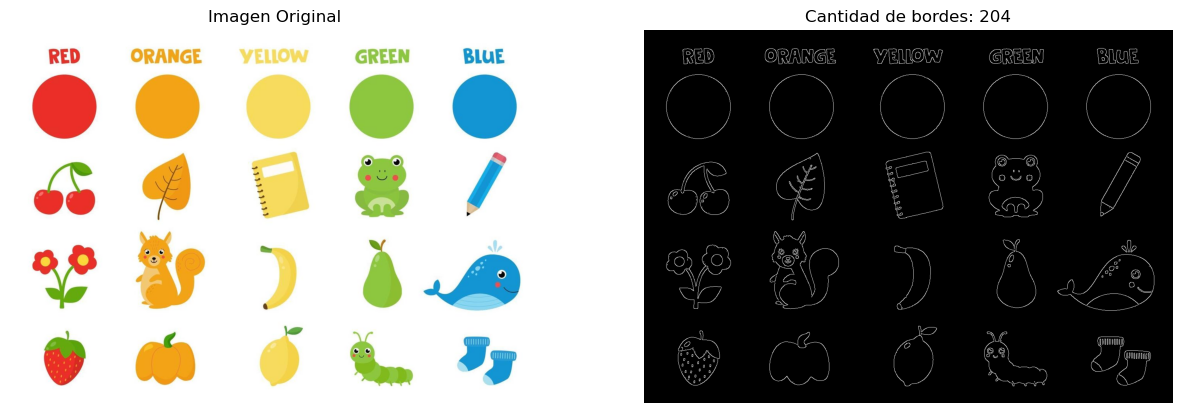

In [40]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

def robertsMejorado(img):
    imgGRAY = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    suavizado = cv2.GaussianBlur(imgGRAY, (3, 3), 0)
    kernelx = np.array([[-2, 0],
                        [0, 2]], dtype=np.float32)
    kernely = np.array([[0, -2],
                        [2, 0]], dtype=np.float32)
    robx = cv2.filter2D(suavizado, cv2.CV_16S, kernelx)
    roby = cv2.filter2D(suavizado, cv2.CV_16S, kernely)

    roberts = cv2.addWeighted(np.abs(robx), 0.5, np.abs(roby), 0.5, 0)
    _, robFinal = cv2.threshold(roberts, 30, 255, cv2.THRESH_BINARY)
    return robFinal

img = cv2.imread('colores.jpg')

imgCANNY = cv2.Canny(img, 100, 200)

contornos, _ = cv2.findContours(imgCANNY, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

plt.figure(figsize=(15, 5))
plt.subplot(121)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(122)
plt.imshow(imgCANNY, cmap='gray')
plt.title(f'Cantidad de bordes: {len(contornos)}')
plt.axis('off')
plt.show()

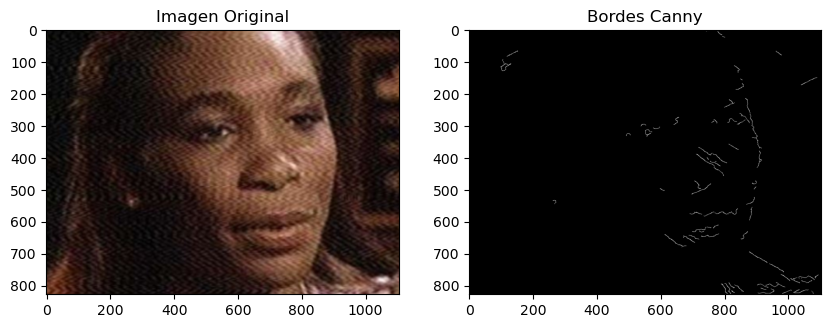

In [41]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen = cv2.imread('imagen distorsionada.jpeg', cv2.IMREAD_COLOR)
img_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(img_gray, (7, 7), 1.5)

bajos = 30
altos = 100

res = cv2.Canny(blur, bajos, altos)

plt.figure(figsize=(10,10))
plt.subplot(1, 2, 1)
plt.title("Imagen Original")
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.subplot(1, 2, 2)
plt.title("Bordes Canny")
plt.imshow(res, cmap='gray')
plt.show()